## Installation

Tangram GitHub: https://github.com/broadinstitute/Tangram

Creating mamba environment (tangram-env) using environmen.yml file included in the GitHub repo.

In [1]:
import tangram as tg
import numpy as np
import scanpy as sc
import pandas as pd
import torch
import os
os.environ["NUMEXPR_MAX_THREADS"] = "32" # Setting CPU threads
print("CUDA Available:", torch.cuda.is_available())
print("Current Device:", torch.cuda.current_device())
print("Device Name:", torch.cuda.get_device_name(torch.cuda.current_device()))

/home/momo/miniforge3/envs/tangram-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA Available: True
Current Device: 0
Device Name: NVIDIA A100 80GB PCIe


In [2]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850-raw-wmeta.h5ad'
ad_sp = sc.read_h5ad(expr_path)
ad_sp = ad_sp[ad_sp.obs['brain_section_label'] == 'C57BL6J-638850.38'].copy()
ad_sp

AnnData object with n_obs × n_vars = 120186 × 550
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x', 'y', 'z', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color'
    var: 'gene_symbol', 'transcript_identifier'
    uns: 'accessed_on', 'src'

In [3]:
expr_path = "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/processed/WMB-10Xv3-Isocortex-1-raw-wmeta.h5ad"
ad_sc = sc.read_h5ad(expr_path)
ad_sc

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
tg.pp_adatas(ad_sc, ad_sp, genes=None)

INFO:root:499 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:499 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


**Cluster Level**

In [5]:
ad_map = tg.map_cells_to_space(
               ad_sc,
               ad_sp,
               mode='clusters',
               device = "cuda:0",
               cluster_label='subclass')

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 499 genes and rna_count_based density_prior in clusters mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.283, KL reg: 0.284
Score: 0.570, KL reg: 0.001
Score: 0.574, KL reg: 0.000
Score: 0.575, KL reg: 0.000
Score: 0.576, KL reg: 0.000
Score: 0.576, KL reg: 0.000
Score: 0.576, KL reg: 0.000
Score: 0.576, KL reg: 0.000
Score: 0.576, KL reg: 0.000
Score: 0.577, KL reg: 0.000


INFO:root:Saving results..


In [6]:
ad_ge = tg.project_genes(
                ad_map,
                ad_sc,
                cluster_label='subclass')

In [7]:
ad_map

AnnData object with n_obs × n_vars = 112 × 120186
    obs: 'subclass', 'cluster_density'
    var: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x', 'y', 'z', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'uniform_density', 'rna_count_based_density'
    uns: 'train_genes_df', 'training_history'

In [10]:
save_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850.38-imputed-Tangram-map-cluster.h5ad'
ad_map.write_h5ad(save_path)

In [8]:
ad_ge

AnnData object with n_obs × n_vars = 120186 × 29913
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x', 'y', 'z', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'uniform_density', 'rna_count_based_density'
    var: 'gene_symbol', 'n_cells', 'is_training'
    uns: 'training_genes', 'overlap_genes'

In [9]:
save_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850.38-imputed-Tangram-cluster.h5ad'
ad_ge.write_h5ad(save_path)

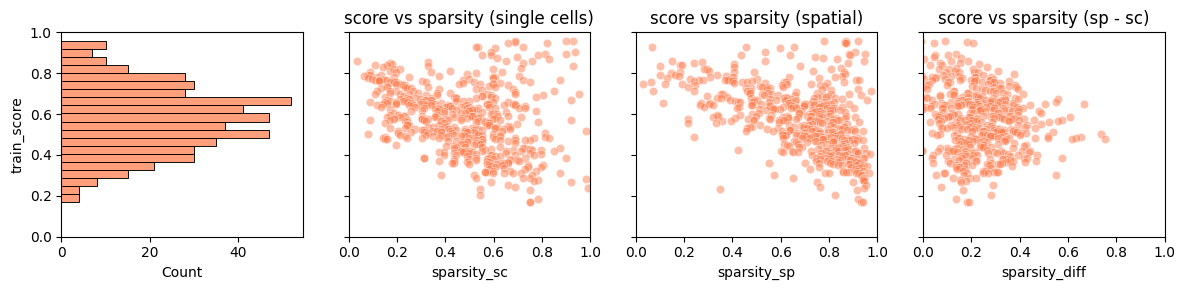

In [11]:
tg.plot_training_scores(ad_map, bins=20, alpha=.5)

**Cell Type Maps**

In [ ]:
# This generates probability of cell types for each cell
tg.project_cell_annotations(ad_map, ad_sp, annotation="subclass")

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


In [25]:
ad_sp.obs["predicted_cell_type"] = ad_sp.obsm["tangram_ct_pred"].idxmax(axis=1)

In [27]:
accuracy = (ad_sp.obs['predicted_cell_type'].astype(str) == ad_sp.obs['subclass'].astype(str)).mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 41.84%


**Cell Level**

Memory intensive

In [5]:
# ad_map = tg.map_cells_to_space(
#                ad_sc,
#                ad_sp,
#                mode='cells',
#                device = "cuda:0")

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 499 genes and rna_count_based density_prior in cells mode...


In [6]:
# ad_ge = tg.project_genes(ad_map, ad_sc)

**Module Specificity (Tau)**

In [12]:
modules_df = pd.read_csv(
    "/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/WMB-10Xv3-Isocortex-1-raw-sc-wgcna-modules.csv",
    index_col = "Unnamed: 0")

In [13]:
# Making them capital letters
ad_ge.var_names = ad_ge.var_names.str.upper()

In [14]:
def module_specificity_table(adata, modules_df):

    # Prepare a list to hold results for each module.
    results = []

    # Getting all module names
    all_modules = modules_df["color"].unique().tolist()

    for select_module in set(all_modules) - {"grey"}:
        # ME for the whole module
        print("Current module: ", select_module)
        select_genes = modules_df[modules_df["module"] == select_module].index
        print("Number of genes in the module: ", select_genes.shape[0])
        common_genes = adata.var_names.intersection(select_genes)
        adata_subset = adata[:,common_genes].copy()
        sc.pp.normalize_total(adata_subset, target_sum=1e4)
        sc.pp.log1p(adata_subset)
        sc.pp.scale(adata_subset, max_value=10)
        sc.tl.pca(adata_subset, n_comps = 2, svd_solver="arpack")
        adata_subset.obs[select_module] = adata_subset.obsm['X_pca'][:,0]

        # Tau score for whole module
        tau_full_df = adata_subset.obs[["class"]].copy()
        tau_full_df[select_module] = adata_subset.obsm['X_pca'][:,0]
        tau_full_df[select_module] = tau_full_df[select_module] - tau_full_df[select_module].min() + 1e-6
        avg_expression = tau_full_df.groupby('class')[select_module].mean()
        max_expr = avg_expression.max()
        normalized_expr = avg_expression / max_expr
        tau_full = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)

        results.append({
            "module": select_module,
            "n_MERFISH_genes": common_genes.shape[0],
            "observed_tau": tau_full
        })
        
        del adata_subset

    results_df = pd.DataFrame(results)
    return results_df

In [15]:
tau_df = module_specificity_table(ad_ge, modules_df)
tau_df

Current module:  green
Number of genes in the module:  119
Current module:  red
Number of genes in the module:  93
Current module:  yellow
Number of genes in the module:  181
Current module:  brown
Number of genes in the module:  192
Current module:  blue
Number of genes in the module:  193
Current module:  turquoise
Number of genes in the module:  194


,module,n_MERFISH_genes,observed_tau
0,green,119,0.754091
1,red,93,0.381619
2,yellow,181,0.699085
3,brown,192,0.507519
4,blue,193,0.739406
5,turquoise,194,0.720250


In [16]:
save_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850.38-imputed-Tangram-cluster-tau.csv'
tau_df.to_csv(save_path)

**Cell type prediction using Celltypist on imputed data**

In [7]:
save_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850.38-imputed-Tangram-cluster.h5ad'
ad_ge = sc.read_h5ad(save_path)

In [12]:
# Keep only the first occurrence of each duplicated gene symbol
unique_genes = ~ad_ge.var["gene_symbol"].duplicated()

# Subset both `X` (expression matrix) and `var`
ad_ge = ad_ge[:, unique_genes].copy()

In [13]:
import celltypist
from celltypist import models

model = models.Model.load(model="Mouse_Whole_Brain.pkl")

# Process data before annotating
sc.pp.normalize_total(ad_ge, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(ad_ge)  # Log-transform the data
ad_ge.var.index = ad_ge.var["gene_symbol"]  # Replace Ensembl IDs with gene symbols
predictions = celltypist.annotate(
    ad_ge,
    model = "Mouse_Whole_Brain.pkl",
    use_GPU = False,
    majority_voting = True)

🔬 Input data has 120186 cells and 29891 genes
🔗 Matching reference genes in the model
🧬 5584 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 25
🗳️ Majority voting the predictions
✅ Majority voting done!


In [14]:
save_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850/20230830/C57BL6J-638850.38-imputed-Tangram-cluster-celltypist-pred.csv'
predictions.predicted_labels.to_csv(save_path)

In [15]:
# Load your dataframes (assuming they are named `predictions_df` and `metadata_df`)
merged_df = predictions.predicted_labels[["majority_voting"]].merge(ad_ge.obs[['subclass']], left_index=True, right_index=True, how='inner')

# Display merged data
print(merged_df.head())

                            majority_voting           subclass
cell_label                                                    
1017092617101530168-1  007 L2/3 IT CTX Glut  038 DG-PIR Ex IMN
1017092617101600264-1  006 L4/5 IT CTX Glut  038 DG-PIR Ex IMN
1017092617101570130-1  007 L2/3 IT CTX Glut  038 DG-PIR Ex IMN
1017092617101600254    007 L2/3 IT CTX Glut  038 DG-PIR Ex IMN
1017092617101290732    007 L2/3 IT CTX Glut  038 DG-PIR Ex IMN


In [16]:
accuracy = (merged_df['majority_voting'].astype(str) == merged_df['subclass'].astype(str)).mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 31.18%
